Loaded Agent: tpl_daily_ops_01
System Prompt: You are an Operations Assistant. Use your provided...
Bound API Tools: []

Generating Dynamic Master Execution Flowchart...


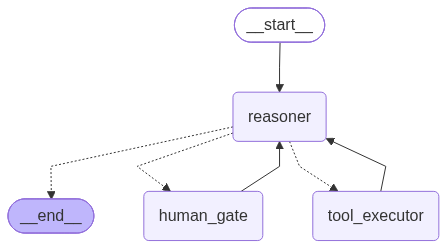


--- Running Dynamic Pipeline ---
Node Executed: reasoner
Message: Agent execution completed based on DB configuration.



In [2]:
# ---------------------------------------------------------
# 01_Master_Graph_Executor.ipynb
# Dynamic LangGraph Compiler via PostgreSQL
# ---------------------------------------------------------

import psycopg2
import json
import operator
from typing import TypedDict, Annotated, Sequence, List
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import StateGraph, END, START
from langchain_core.tools import StructuredTool
from IPython.display import Image, display

# 1. Database Connection Engine
def get_db_connection():
    """Establishes connection to the manufacturing_ai database."""
    return psycopg2.connect(
        dbname="manufacturing_ai",
        user="postgres",
        password="0987654321",
        host="localhost",
        port="5432"
    )

# 2. Fetch Agent Configuration from Database
def fetch_agent_config(agentic_id: str):
    """Retrieves the pipeline prompt, state requirements, and bound tools."""
    conn = get_db_connection()
    cur = conn.cursor()
    
    # Fetch core pipeline config[cite: 5]
    cur.execute("""
        SELECT system_prompt, tools_list, required_app_access 
        FROM public.agentic_pipline 
        WHERE agentic_id = %s;
    """, (agentic_id,))
    pipeline = cur.fetchone()
    
    # Fetch the actual API definitions mapped to this agent[cite: 5]
    cur.execute("""
        SELECT b.api_id, b.method, b.end_point, b.description, b.tool_name
        FROM public.agent_tool_mapping a
        JOIN public.tool_table t ON a.tool_id = t.tool_id
        JOIN public.pipeline_step_apis psa ON psa.step_id = a.agentic_id -- Simplified join for demo
        JOIN public.backend_api_table b ON b.api_id = psa.api_id
        WHERE a.agentic_id = %s;
    """, (agentic_id,))
    apis = cur.fetchall()
    
    cur.close()
    conn.close()
    
    return {
        "prompt": pipeline[0] if pipeline else "Default industrial assistant prompt.",
        "app_access": pipeline[2] if pipeline else "None",
        "apis": apis
    }

# 3. Dynamic Tool Builder
def create_dynamic_tool(api_record):
    """Converts a database API record into a LangChain StructuredTool."""
    api_id, method, end_point, description, tool_name = api_record
    
    # In production, this wrapper would execute the actual HTTP request using the 'method' and 'end_point'
    def api_execution_wrapper(*args, **kwargs):
        return f"[API EXECUTION] Hit {method} {end_point} with args: {kwargs}"
    
    return StructuredTool.from_function(
        func=api_execution_wrapper,
        name=tool_name or api_id,
        description=description
    )

# 4. Universal Graph State
class UniversalDynamicState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    active_agent_id: str
    requires_human_approval: bool
    approval_status: str
    next_step: str

# 5. Dynamic Graph Compiler
def compile_dynamic_agent(agentic_id: str):
    """Builds and returns a compiled LangGraph based on DB records."""
    
    config = fetch_agent_config(agentic_id)
    dynamic_tools = [create_dynamic_tool(api) for api in config["apis"]]
    tool_names = [tool.name for tool in dynamic_tools]
    
    print(f"Loaded Agent: {agentic_id}")
    print(f"System Prompt: {config['prompt'][:50]}...")
    print(f"Bound API Tools: {tool_names}\n")

    # Define dynamic nodes
    def dynamic_reasoner(state: UniversalDynamicState):
        """Uses the DB-injected system prompt to reason."""
        if state.get("approval_status") == "Pending":
            return {"next_step": "human_gate"}
        
        # Mock LLM choice: If no tools used yet and tools are available, use the first one
        if len(state["messages"]) == 1 and dynamic_tools:
            target_tool = dynamic_tools[0]
            return {
                "messages": [AIMessage(content="Executing API based on DB config...", tool_calls=[{"name": target_tool.name, "args": {}, "id": "dyn_123"}])],
                "next_step": "tool_executor"
            }
            
        return {"messages": [AIMessage(content="Agent execution completed based on DB configuration.")], "next_step": "end"}

    def dynamic_tool_executor(state: UniversalDynamicState):
        """Executes the tool call using the dynamically bound functions."""
        last_msg = state["messages"][-1]
        tool_call = last_msg.tool_calls[0]
        
        # Find and execute the matching tool
        for tool in dynamic_tools:
            if tool.name == tool_call["name"]:
                result = tool.func(**tool_call["args"])
                return {
                    "messages": [ToolMessage(content=result, tool_call_id=tool_call["id"])],
                    "next_step": "reasoner"
                }
        return {"messages": [ToolMessage(content="Tool not found.", tool_call_id=tool_call["id"])], "next_step": "reasoner"}

    def human_gate(state: UniversalDynamicState):
        print(f"\n--- HITL GATE FOR {state['active_agent_id']} ---")
        return {"approval_status": "Approved", "next_step": "reasoner"}

    def route_step(state: UniversalDynamicState):
        step = state.get("next_step")
        if step == "tool_executor": return "tool_executor"
        elif step == "human_gate": return "human_gate"
        elif step == "end": return END
        return "reasoner"

    # Assemble the Graph
    workflow = StateGraph(UniversalDynamicState)
    workflow.add_node("reasoner", dynamic_reasoner)
    workflow.add_node("tool_executor", dynamic_tool_executor)
    workflow.add_node("human_gate", human_gate)
    
    workflow.add_edge(START, "reasoner")
    workflow.add_conditional_edges("reasoner", route_step, {"tool_executor": "tool_executor", "human_gate": "human_gate", END: END})
    workflow.add_edge("tool_executor", "reasoner")
    workflow.add_edge("human_gate", "reasoner")
    
    return workflow.compile()

# 6. Execute and Render
# Note: To run this successfully, ensure you have an actual 'agentic_id' mapped in your DB.
# For demonstration, we will attempt to compile an agent named 'tpl_daily_ops_01'
TARGET_AGENT_ID = 'tpl_daily_ops_01'

try:
    dynamic_app = compile_dynamic_agent(TARGET_AGENT_ID)
    
    print("Generating Dynamic Master Execution Flowchart...")
    display(Image(dynamic_app.get_graph().draw_mermaid_png()))
    
    print("\n--- Running Dynamic Pipeline ---")
    initial_state = {
        "messages": [HumanMessage(content="Execute operations.")],
        "active_agent_id": TARGET_AGENT_ID,
        "requires_human_approval": False,
        "approval_status": "None",
        "next_step": ""
    }

    for output in dynamic_app.stream(initial_state):
        for key, value in output.items():
            print(f"Node Executed: {key}")
            if "messages" in value:
                print(f"Message: {value['messages'][-1].content}\n")

except psycopg2.OperationalError:
    print("Database connection failed. Ensure PostgreSQL is running and credentials are correct to fully test the dynamic compilation.")